In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df["Churn"].value_counts() #The dataset is imbalanced , with more non churn customers than churn customers.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
# churn rate (1869/(1869+5174) = approximately 26%
# If the churn rate is approximately 26% this means that about one out of every four customers leaves.This represents a significant customer loss and makes churn prediction an important business problem.

In [10]:
df.groupby("Churn")["MonthlyCharges"].mean() # Customers who churn pay higher monthly charges.This shows that higher prices may lead to customer loss.

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [11]:
df.groupby("Churn")["tenure"].mean() #Customers who churn have lower tenure approximately 18 months.This shows that higher prices may lead to customer loss.

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [12]:
df.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [13]:
# Customers with mont to month contracts have higher churn rate approximately 42% compared to those with one year 11% and two year %2 . This indicates that customers with short term contracts are more likely to churn wihile customers with long term contracts tend to stay.

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [17]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [18]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [19]:
df = df.dropna()

In [20]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [21]:
df["Churn"]=df["Churn"].map({"Yes": 1, "No": 0})

In [22]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [23]:
X = pd.get_dummies(X,drop_first=True) #categorical to numeric

In [24]:
# train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [25]:
#Problem is about Classification that's why I used Logisticregression

from sklearn.linear_model import LogisticRegression

In [26]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/linear_

LogisticRegression(max_iter=1000)

In [27]:
from sklearn.metrics import accuracy_score #accuracy score gives to prediction about how many customer they are going to churn?
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)

/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.78839590443686

## Model Compare
Include Logistic Regression , I m going to train Random forest and XGBoost
We had warning problem and we solved because I add scaling.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
#LOGISTIC REGRESSION (Scaled)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn']))

=== Logistic Regression ===
Accuracy: 0.7844

              precision    recall  f1-score   support

    No Churn       0.80      0.95      0.87      1300
       Churn       0.69      0.31      0.43       458

    accuracy                           0.78      1758
   macro avg       0.75      0.63      0.65      1758
weighted avg       0.77      0.78      0.75      1758



/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/linear_

In [30]:
# --- RANDOM FOREST ---
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # RF no need scaling
rf_pred = rf_model.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
print()
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))

=== Random Forest ===
Accuracy: 0.7901

              precision    recall  f1-score   support

    No Churn       0.82      0.92      0.87      1300
       Churn       0.64      0.43      0.52       458

    accuracy                           0.79      1758
   macro avg       0.73      0.67      0.69      1758
weighted avg       0.78      0.79      0.78      1758



In [31]:
# XGBOOST
#libomp library was set up
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print('=== XGBoost ===')
print(f'Accuracy: {accuracy_score(y_test, xgb_pred):.4f}')
print()
print(classification_report(y_test, xgb_pred, target_names=['No Churn', 'Churn']))

=== XGBoost ===
Accuracy: 0.7787

              precision    recall  f1-score   support

    No Churn       0.83      0.87      0.85      1300
       Churn       0.59      0.51      0.54       458

    accuracy                           0.78      1758
   macro avg       0.71      0.69      0.70      1758
weighted avg       0.77      0.78      0.77      1758



In [32]:
#Model Compare Table
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'F1 (Churn)': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
    ]
}).round(4)

print(results.to_string(index=False))

/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emrekaya/PycharmProjects/PythonProject5/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


              Model  Accuracy  F1 (Churn)  ROC-AUC
Logistic Regression    0.7844      0.4266   0.8292
      Random Forest    0.7901      0.5189   0.8221
            XGBoost    0.7787      0.5440   0.8115


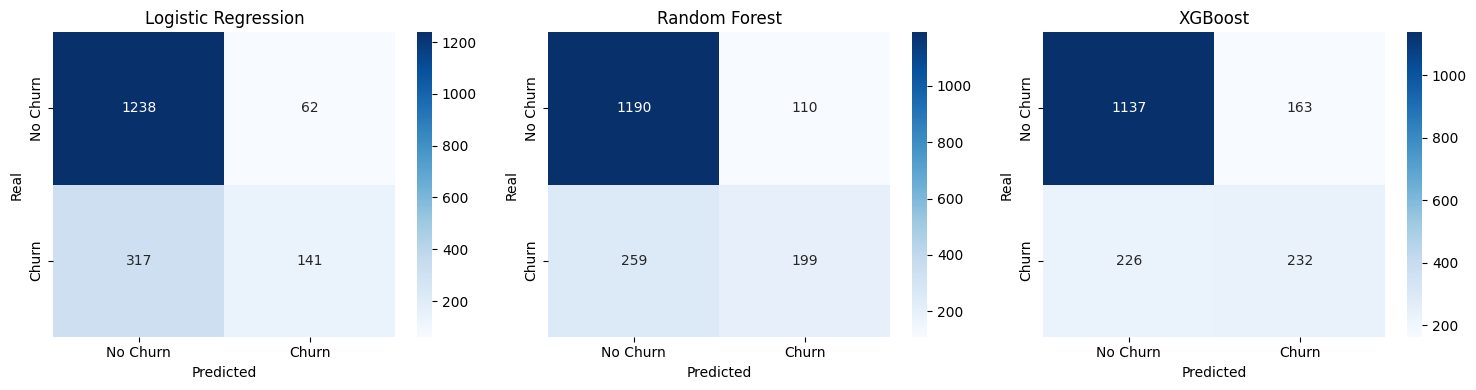

confusion_matrices.png saved.


In [37]:
# CONFUSION MATRIX
# (The best model : XGBoost)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pred, name in zip(axes,
                           [lr_pred, rf_pred, xgb_pred],
                           ['Logistic Regression', 'Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('confusion_matrices.png saved.')

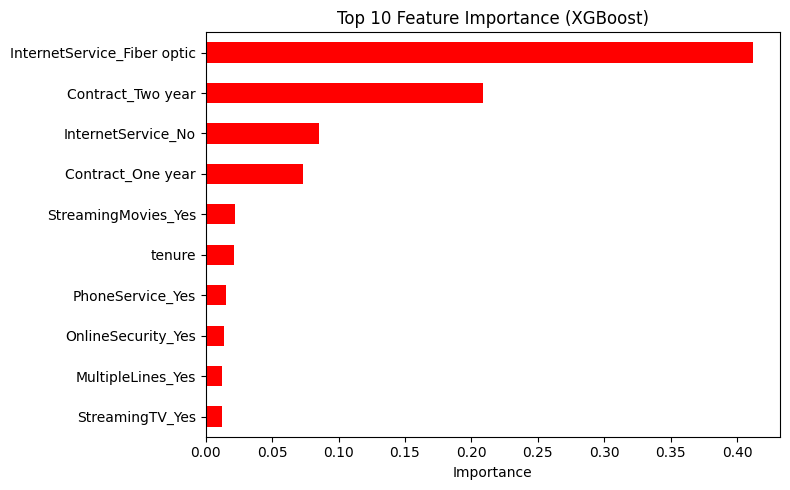

feature_importance.png saved


In [40]:
# --- FEATURE IMPORTANCE (XGBoost) ---
import matplotlib.pyplot as plt
import pandas as pd

feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top10 = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10.plot(kind='barh', color='red')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('feature_importance.png saved')